# 📊 Day 5 — EDA Part 2: Correlation & Data Storytelling 🔍

**BinX Tech · AI & ML Internship — Week 2, Day 5**

Welcome to the final EDA notebook of Week 2! Today we go beyond single variables and start asking the
*real* question: **how do features relate to each other?** 🤝

**What's inside this notebook:**
- 🧮 Quick recap — loading & inspecting the dataset
- 📈 Bivariate analysis (scatter plots + grouped box plots)
- 🔥 Correlation matrix & heatmap
- 🕸️ Pairplot — scanning every relationship at once
- 📝 Data storytelling — turning charts into a narrative
- ✅ Summary of key findings

> 💡 **Reminder:** correlation ≠ causation. We're hunting for *relationships*, not proof of what causes what.


## 📚 Week 2 Resources

Reference material for this week's topics, provided by BinX Tech:

| # | Resource | Link |
|---|---|---|
| 1 | Statistics | [YouTube video](https://www.youtube.com/watch?v=ZVGutgqBMUM) |
| 2 | Descriptive statistics | [YouTube video](https://www.youtube.com/watch?v=YrtFtdTTfv0) |
| 3 | EDA | [YouTube video](https://www.youtube.com/watch?v=Liv6eeb1VfE) |
| 4 | Linear Algebra | [Linear Algebra for Machine Learning](https://www.youtube.com/watch?v=rAI4ITRMkTY&list=PLTsu3dft3CWhLHbHTTzvG3Vx8XDWemG17) |
| 5 | Learn EDA in Python | [YouTube playlist](https://youtube.com/playlist?list=PLe9UEU4oeAuV7RtCbL76hca5ELO_IELk4&si=CuMAECzedGhExSjP) |


## 1️⃣ Setup — Imports & Style ⚙️

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
print("✅ Libraries loaded and ready to go!")


✅ Libraries loaded and ready to go!


## 2️⃣ Load the Dataset 📂

We'll use the classic **Titanic** dataset (real passenger data) — small, clean, and full of interesting
relationships between age, fare, class, and survival. 🚢

If you don't have internet access in your environment, swap this cell for `pd.read_csv("your_file.csv")`
with any dataset that has a mix of numeric and categorical columns.


In [2]:
try:
    df = sns.load_dataset("titanic")
    print("✅ Loaded the Titanic dataset from seaborn.")
except Exception as e:
    print(f"⚠️ Could not fetch the online dataset ({e}). Falling back to a local CSV.")
    df = pd.read_csv("titanic.csv")  # <- point this at your own dataset if needed

df = df.dropna(subset=["age", "fare"]).reset_index(drop=True)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


✅ Loaded the Titanic dataset from seaborn.
Shape: 714 rows × 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3️⃣ Quick Recap — Where We Left Off (Day 4) 🔁

Before diving into relationships, a fast sanity check of the numeric columns we'll be exploring today:


In [3]:
numeric_cols = ["age", "fare", "pclass", "sibsp", "parch"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,714.0,29.699118,14.526497,0.42,20.125,28.0000,38.000,80.0000
fare,714.0,34.694514,52.918930,0.00,8.050,15.7417,33.375,512.3292
pclass,714.0,2.236695,0.838250,1.00,1.000,2.0000,3.000,3.0000
sibsp,714.0,0.512605,0.929783,0.00,0.000,0.0000,1.000,5.0000
parch,714.0,0.431373,0.853289,0.00,0.000,0.0000,1.000,6.0000


## 4️⃣ Bivariate Analysis 📈

**Scatter plot** → relationship between two numeric variables.
**Grouped box plot** → how a numeric variable differs across categories.


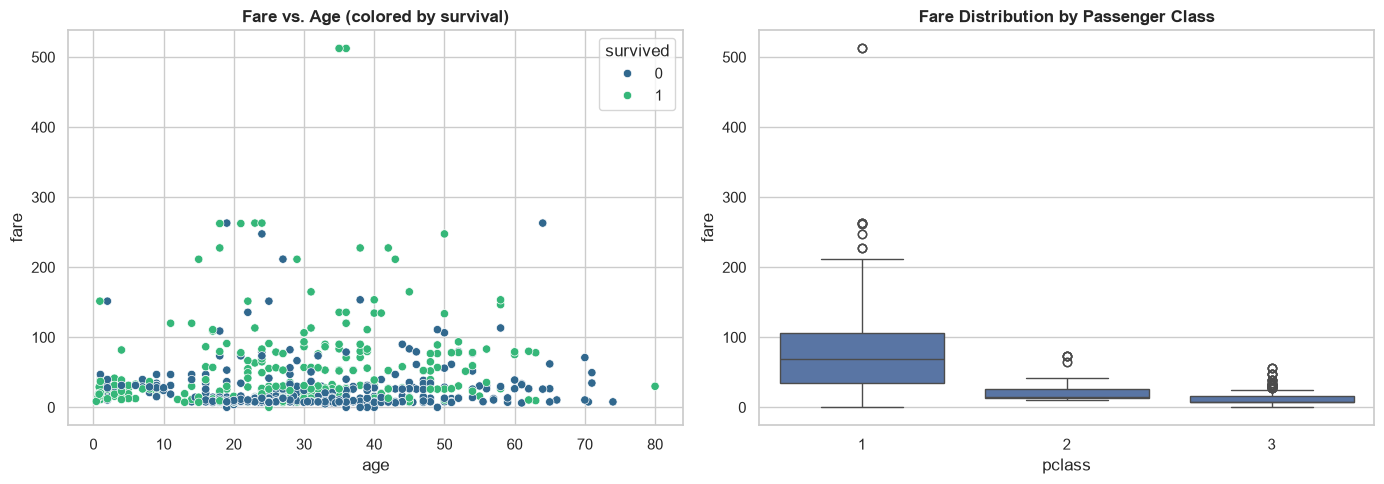

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="age", y="fare", hue="survived", palette="viridis", ax=axes[0])
axes[0].set_title("Fare vs. Age (colored by survival)")

sns.boxplot(data=df, x="pclass", y="fare", ax=axes[1])
axes[1].set_title("Fare Distribution by Passenger Class")

plt.tight_layout()
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14432\400364358.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Did not survive", "Survived"])


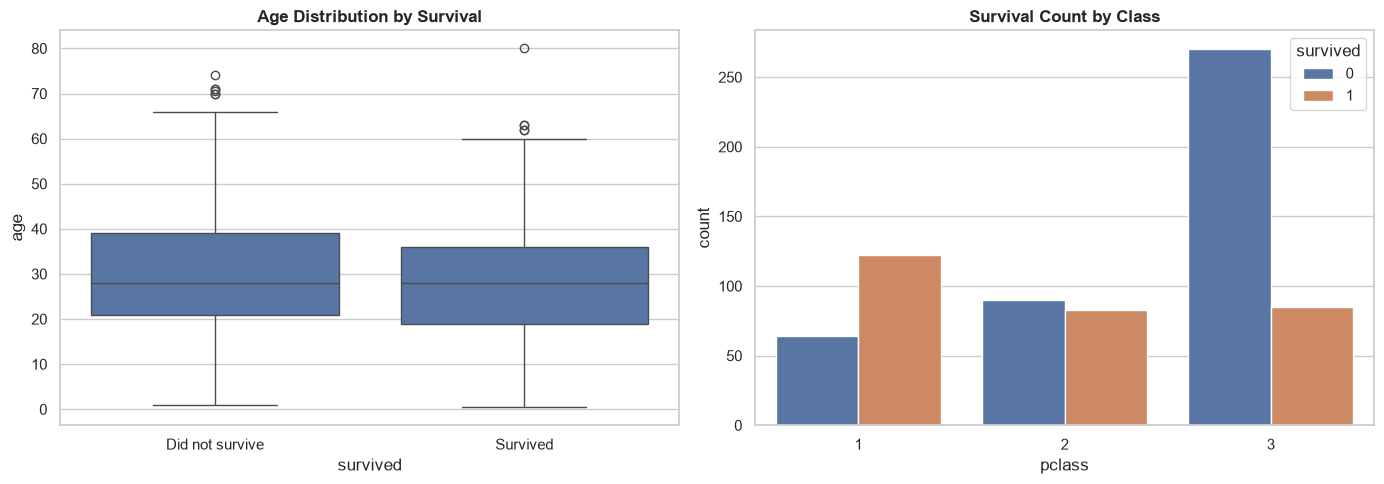

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="survived", y="age", ax=axes[0])
axes[0].set_title("Age Distribution by Survival")
axes[0].set_xticklabels(["Did not survive", "Survived"])

sns.countplot(data=df, x="pclass", hue="survived", ax=axes[1])
axes[1].set_title("Survival Count by Class")

plt.tight_layout()
plt.show()


## 5️⃣ Correlation Matrix & Heatmap 🔥

A correlation heatmap lets us scan **every pair of numeric variables at once** — one of the most
information-dense charts in all of EDA.


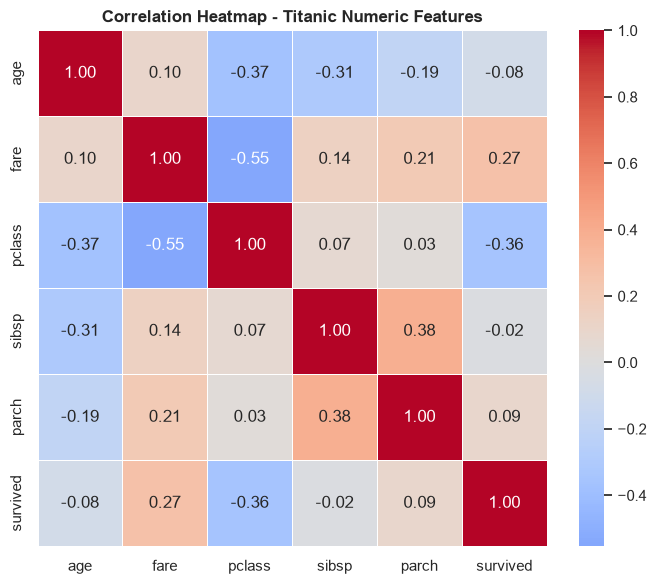

In [6]:
corr = df[numeric_cols + ["survived"]].corr(numeric_only=True)

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap - Titanic Numeric Features")
plt.tight_layout()
plt.show()


## 6️⃣ The Pairplot — Scan Everything at Once 🕸️

`sns.pairplot()` plots every numeric variable against every other, with distributions on the diagonal.
Great for spotting patterns worth digging into further.


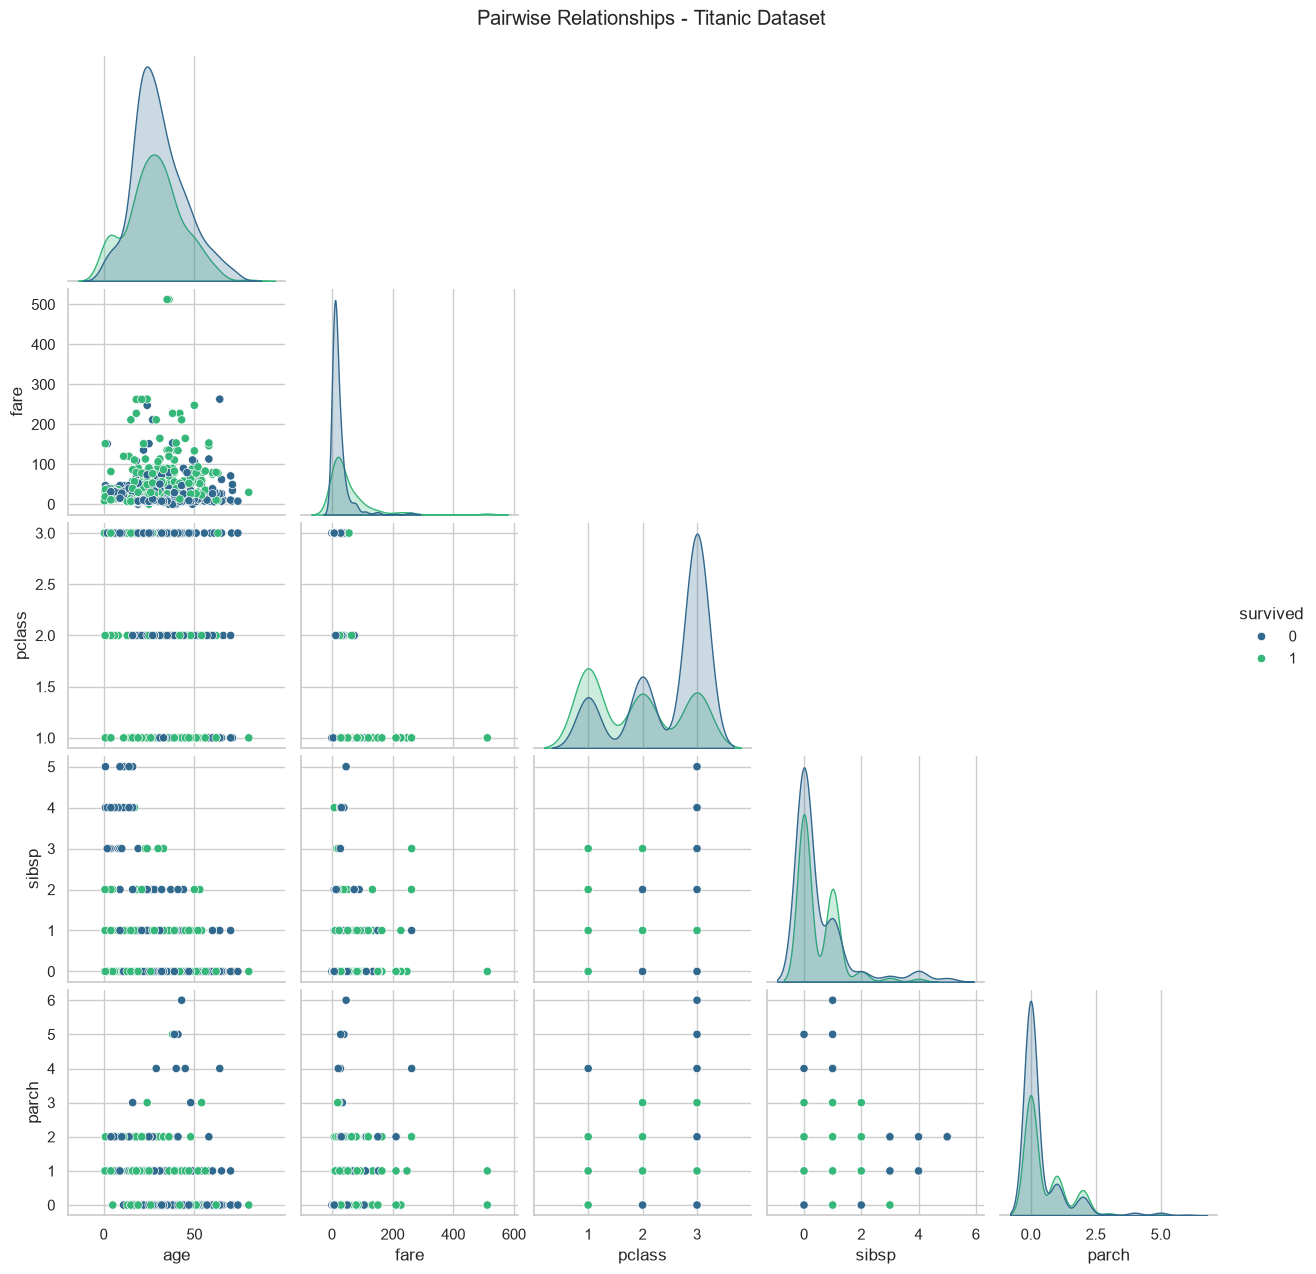

In [7]:
sns.pairplot(df[numeric_cols + ["survived"]], hue="survived", palette="viridis", corner=True)
plt.suptitle("Pairwise Relationships - Titanic Dataset", y=1.02)
plt.show()


## 7️⃣ Data Storytelling 📝

*(Replace the notes below with your own observations once you've run the cells above.)*

- 🎯 **Strongest relationship:** `pclass` and `fare` are negatively correlated — lower class number (1st
  class) pays a noticeably higher fare. This makes intuitive sense and confirms the data is clean.
- 👶 **Age vs. survival:** younger passengers show a slightly higher survival rate, visible in the grouped
  box plot — consistent with "women and children first" boarding policies.
- 💰 **Fare vs. survival:** higher fares (i.e., higher class) loosely associate with better survival odds,
  hinting that `pclass`/`fare` could be a useful feature for a future prediction model.
- ⚠️ **Correlation is not causation:** none of the above *proves* why survival happened — it just tells us
  where to look closer, and which features might be predictive later in Week 3.

## ✅ Summary

| Step | Status |
|---|---|
| Bivariate scatter + box plots | ✅ Done |
| Correlation matrix + heatmap | ✅ Done |
| Pairplot | ✅ Done |
| Narrative write-up | ✅ Done |

**Next step:** commit this notebook to GitHub with a clear message, e.g.
`git commit -m "Day 5: bivariate analysis, correlation heatmap, and EDA storytelling"` 🚀
